In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from google.colab import files

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV


In [2]:
#upload the dataset

uploaded = files.upload()

Saving datasetMV.csv to datasetMV.csv


In [3]:
data_path = "datasetMV.csv"

df = pd.read_csv(data_path)
print("Shape:", df.shape)
df.head()

Shape: (1000, 35)


,Timestamp,Column 1,Patient Identification Number,age,gender,height,weight,occupation,physical_activity_level,living_environment,...,cs,cholesterol,crp,esr,rf,fbc,What is the current severity level of the patients knee osteoarthritis,Does the patient have any other health conditions or risk factors that may contribute to knee osteoarthritis,What are the suggested or ongoing treatments for the patients current condition,KOA
0,2023-07-17 08:54:00,C1-6715,PID0471,48,male,171.6,62.3,yes,low,urban,...,NaN,NaN,1.85,NaN,NaN,13.64,none,low physical activity,exercise advice and monitoring,no
1,2024-12-22 14:21:00,C1-5239,PID0206,42,male,165.9,65.4,yes,high,urban,...,0.96,NaN,6.44,NaN,NaN,14.09,mild,hypertension,exercise advice and monitoring,yes
2,2023-03-04 15:50:00,C1-6290,PID0696,48,female,150.2,59.0,yes,high,rural,...,0.93,NaN,4.20,NaN,3.60,14.17,none,hypertension,follow-up review with conservative management,no
3,2024-01-14 17:42:00,C1-3597,PID0534,29,female,152.9,82.8,yes,low,urban,...,1.04,150.3,3.83,10.5,NaN,NaN,none,"obesity, low physical activity",exercise advice and monitoring,no
4,2024-11-14 17:19:00,C1-9788,PID1002,50,female,155.4,69.1,no,low,rural,...,0.68,190.5,NaN,18.6,10.46,14.27,moderate,"vitamin D deficiency, previous knee injury, lo...",quadriceps strengthening and lifestyle counseling,no


In [4]:
#checking the total number of duplicate columns

df.duplicated().sum()

np.int64(0)

In [5]:
# List of columns that want to remove

columns_to_remove = [
    "Timestamp",
    "Column 1",
    "Patient Identification Number",
    "What is the current severity level of the patients knee osteoarthritis",
    "Does the patient have any other health conditions or risk factors that may contribute to knee osteoarthritis",
    "What are the suggested or ongoing treatments for the patients current condition"
]

# Only drop columns that actually exist in df
columns_to_drop = [c for c in columns_to_remove if c in df.columns]

df = df.drop(columns=columns_to_drop)

print("Dropped columns:", columns_to_drop)
print("New shape:", df.shape)
df.head()

Dropped columns: ['Timestamp', 'Column 1', 'Patient Identification Number', 'What is the current severity level of the patients knee osteoarthritis', 'Does the patient have any other health conditions or risk factors that may contribute to knee osteoarthritis', 'What are the suggested or ongoing treatments for the patients current condition']
New shape: (1000, 29)


,age,gender,height,weight,occupation,physical_activity_level,living_environment,knee_pain,knee_pain_in_past_week,stifness_after_resting,...,fbs,wbc,platelets,cs,cholesterol,crp,esr,rf,fbc,KOA
0,48,male,171.6,62.3,yes,low,urban,no,4,never,...,93.0,8431.0,318897.0,NaN,NaN,1.85,NaN,NaN,13.64,no
1,42,male,165.9,65.4,yes,high,urban,yes,1,occasionally,...,105.5,NaN,160197.0,0.96,NaN,6.44,NaN,NaN,14.09,yes
2,48,female,150.2,59.0,yes,high,rural,no,4,always,...,83.2,NaN,NaN,0.93,NaN,4.20,NaN,3.60,14.17,no
3,29,female,152.9,82.8,yes,low,urban,no,3,frequently,...,100.4,NaN,335077.0,1.04,150.3,3.83,10.5,NaN,NaN,no
4,50,female,155.4,69.1,no,low,rural,yes,4,always,...,107.3,9167.0,261685.0,0.68,190.5,NaN,18.6,10.46,14.27,no


In [6]:
#performing EDA

df.info()
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1000 non-null   int64  
 1   gender                    1000 non-null   object 
 2   height                    1000 non-null   float64
 3   weight                    1000 non-null   float64
 4   occupation                1000 non-null   object 
 5   physical_activity_level   1000 non-null   object 
 6   living_environment        1000 non-null   object 
 7   knee_pain                 1000 non-null   object 
 8   knee_pain_in_past_week    1000 non-null   int64  
 9   stifness_after_resting    1000 non-null   object 
 10  knee_injuries             1000 non-null   object 
 11  swelling                  1000 non-null   object 
 12  difficulty_in_performing  1000 non-null   object 
 13  family_history            1000 non-null   object 
 14  obesity  

,age,gender,height,weight,occupation,physical_activity_level,living_environment,knee_pain,knee_pain_in_past_week,stifness_after_resting,...,fbs,wbc,platelets,cs,cholesterol,crp,esr,rf,fbc,KOA
count,1000.000000,1000,1000.000000,1000.000000,1000,1000,1000,1000,1000.0000,1000,...,760.000000,760.000000,760.000000,760.000000,760.000000,760.000000,760.000000,760.000000,760.000000,1000
unique,NaN,2,NaN,NaN,2,3,2,2,NaN,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,female,NaN,NaN,yes,moderate,urban,yes,NaN,never,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no
freq,NaN,557,NaN,NaN,671,423,576,517,NaN,304,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500
mean,53.497000,NaN,163.436300,73.221600,NaN,NaN,NaN,NaN,2.9960,NaN,...,97.650921,6952.696053,269458.911842,0.944421,197.030132,3.348592,16.309079,8.323118,13.775566,NaN
std,11.080468,NaN,10.246287,15.220781,NaN,NaN,NaN,NaN,1.4954,NaN,...,12.685631,1325.156776,54942.148956,0.151495,22.552586,2.172722,8.141063,2.771770,1.011460,NaN
min,22.000000,NaN,145.000000,38.100000,NaN,NaN,NaN,NaN,1.0000,NaN,...,70.000000,4000.000000,150000.000000,0.600000,141.600000,0.000000,0.000000,0.500000,11.000000,NaN
25%,46.000000,NaN,155.775000,62.025000,NaN,NaN,NaN,NaN,2.0000,NaN,...,88.100000,6036.750000,230279.000000,0.840000,181.000000,1.675000,9.900000,6.430000,13.060000,NaN
50%,53.000000,NaN,163.100000,71.850000,NaN,NaN,NaN,NaN,3.0000,NaN,...,97.100000,6895.500000,270815.500000,0.940000,195.850000,2.895000,15.350000,8.440000,13.780000,NaN
75%,61.000000,NaN,171.300000,83.825000,NaN,NaN,NaN,NaN,4.0000,NaN,...,106.500000,7880.500000,305986.250000,1.040000,213.825000,4.870000,22.200000,10.422500,14.410000,NaN


In [7]:
#check for missing values

df.isna().sum().sort_values(ascending=False)

,0
crp,240
esr,240
rf,240
wbc,240
fbc,240
platelets,240
cs,240
cholesterol,240
fbs,240
gender,0


In [8]:
#view all columns

df.columns.tolist()

['age',
 'gender',
 'height',
 'weight',
 'occupation',
 'physical_activity_level',
 'living_environment',
 'knee_pain',
 'knee_pain_in_past_week',
 'stifness_after_resting',
 'knee_injuries',
 'swelling',
 'difficulty_in_performing',
 'family_history',
 'obesity',
 'diabetes',
 'hypertension',
 'vitaminD_deficiency',
 'rheumatoid_arthritis',
 'fbs',
 'wbc',
 'platelets',
 'cs',
 'cholesterol',
 'crp',
 'esr',
 'rf',
 'fbc',
 'KOA']

In [9]:
#handling missing values in categorical columns

df['difficulty_in_performing'] = df['difficulty_in_performing'].fillna(df['difficulty_in_performing'].mode()[0])

In [10]:
#handling missing values in numerical columns

def clean_numeric(col):
    df[col] = df[col].astype(str)
    df[col] = df[col].str.replace("mm", "", regex=False)
    df[col] = df[col].str.replace("MM", "", regex=False)
    df[col] = df[col].str.replace(" ", "", regex=False)
    df[col] = df[col].str.replace("\u200b", "", regex=False)  # zero-width space
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Clean and fill FBC
clean_numeric('fbc')
df['fbc'] = df['fbc'].fillna(df['fbc'].median())

# CRP
clean_numeric('crp')
df['crp'] = df['crp'].fillna(df['crp'].median())

# CS (Calcium Serum)
clean_numeric('cs')
df['cs'] = df['cs'].fillna(df['cs'].median())

# ESR
clean_numeric('esr')
df['esr'] = df['esr'].fillna(df['esr'].median())

# WBC
clean_numeric('wbc')
df['wbc'] = df['wbc'].fillna(df['wbc'].median())

# RF
clean_numeric('rf')
df['rf'] = df['rf'].fillna(df['rf'].median())

# Cholesterol
clean_numeric('cholesterol')
df['cholesterol'] = df['cholesterol'].fillna(df['cholesterol'].median())

# FBS
clean_numeric('fbs')
df['fbs'] = df['fbs'].fillna(df['fbs'].median())

#platelets
clean_numeric('platelets')
df['platelets'] = df['platelets'].fillna(df['platelets'].median())

In [11]:
#check for missing values after filling the missing values

df.isna().sum().sort_values(ascending=False)

,0
age,0
gender,0
height,0
weight,0
occupation,0
physical_activity_level,0
living_environment,0
knee_pain,0
knee_pain_in_past_week,0
stifness_after_resting,0


In [12]:
df.dtypes

,0
age,int64
gender,object
height,float64
weight,float64
occupation,object
physical_activity_level,object
living_environment,object
knee_pain,object
knee_pain_in_past_week,int64
stifness_after_resting,object


In [13]:
#encoding the dependent variable

df = df.rename(columns={'KOA': 'KOA'})
df['KOA'] = df['KOA'].map({'yes': 1, 'no': 0})

In [14]:
#Label encoding for binary columns

le = LabelEncoder()

binary_cols = [
    'gender',
    'occupation',
    'living_environment',
    'knee_pain',
    'stifness_after_resting',
    'knee_injuries',
    'swelling',
    'difficulty_in_performing',
    'family_history',
    'obesity',
    'diabetes',
    'hypertension',
    'vitaminD_deficiency',
    'rheumatoid_arthritis'
]

for col in binary_cols:
    df[col] = le.fit_transform(df[col])

In [15]:
df.head()

,age,gender,height,weight,occupation,physical_activity_level,living_environment,knee_pain,knee_pain_in_past_week,stifness_after_resting,...,fbs,wbc,platelets,cs,cholesterol,crp,esr,rf,fbc,KOA
0,48,1,171.6,62.3,1,low,1,0,4,2,...,93.0,8431.0,318897.0,0.94,195.85,1.850,15.35,8.44,13.64,0
1,42,1,165.9,65.4,1,high,1,1,1,3,...,105.5,6895.5,160197.0,0.96,195.85,6.440,15.35,8.44,14.09,1
2,48,0,150.2,59.0,1,high,0,0,4,0,...,83.2,6895.5,270815.5,0.93,195.85,4.200,15.35,3.60,14.17,0
3,29,0,152.9,82.8,1,low,1,0,3,1,...,100.4,6895.5,335077.0,1.04,150.30,3.830,10.50,8.44,13.78,0
4,50,0,155.4,69.1,0,low,0,1,4,0,...,107.3,9167.0,261685.0,0.68,190.50,2.895,18.60,10.46,14.27,0


In [16]:
#One-Hot encoding for multi class columns

multi_cols = [
    'physical_activity_level'
    ]

df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

In [17]:
# Quick check

print(df.dtypes.value_counts())
print("Final shape:", df.shape)

int64      17
float64    11
bool        2
Name: count, dtype: int64
Final shape: (1000, 30)


In [18]:
#calculate BMI using height and weight column

df['BMI'] = df['weight'] / ((df['height'] / 100) ** 2)

In [19]:
df.columns.tolist()

['age',
 'gender',
 'height',
 'weight',
 'occupation',
 'living_environment',
 'knee_pain',
 'knee_pain_in_past_week',
 'stifness_after_resting',
 'knee_injuries',
 'swelling',
 'difficulty_in_performing',
 'family_history',
 'obesity',
 'diabetes',
 'hypertension',
 'vitaminD_deficiency',
 'rheumatoid_arthritis',
 'fbs',
 'wbc',
 'platelets',
 'cs',
 'cholesterol',
 'crp',
 'esr',
 'rf',
 'fbc',
 'KOA',
 'physical_activity_level_low',
 'physical_activity_level_moderate',
 'BMI']

In [20]:
#seperate x, y

X = df.drop('KOA', axis=1)
y = df['KOA']

print("\nFeature matrix shape:", X.shape)
print("Target distribution:\n", y.value_counts())


Feature matrix shape: (1000, 30)
Target distribution:
 KOA
0    500
1    500
Name: count, dtype: int64


In [21]:
print(y.isna().sum())

0


In [22]:
print(df.columns.tolist())
print(df["KOA"].isna().sum())
print(df["KOA"].value_counts(dropna=False))

['age', 'gender', 'height', 'weight', 'occupation', 'living_environment', 'knee_pain', 'knee_pain_in_past_week', 'stifness_after_resting', 'knee_injuries', 'swelling', 'difficulty_in_performing', 'family_history', 'obesity', 'diabetes', 'hypertension', 'vitaminD_deficiency', 'rheumatoid_arthritis', 'fbs', 'wbc', 'platelets', 'cs', 'cholesterol', 'crp', 'esr', 'rf', 'fbc', 'KOA', 'physical_activity_level_low', 'physical_activity_level_moderate', 'BMI']
0
KOA
0    500
1    500
Name: count, dtype: int64


In [23]:
#split the dataset into training and testing

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

print("\nTrain shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (800, 30)  Test shape: (200, 30)


In [24]:
#Handling class imbalance

sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)

print("After SMOTE:", X_train.shape, "label counts:", y_train.value_counts())

After SMOTE: (800, 30) label counts: KOA
1    400
0    400
Name: count, dtype: int64


In [25]:
#standardize numeric columns

numeric_cols = [
    'age', 'height', 'weight',
    'knee_pain_in_past_week',
    'fbs', 'wbc', 'platelets', 'cs',
    'cholesterol', 'crp', 'esr', 'rf', 'fbc', 'BMI'
]

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [26]:
X.head()

,age,gender,height,weight,occupation,living_environment,knee_pain,knee_pain_in_past_week,stifness_after_resting,knee_injuries,...,platelets,cs,cholesterol,crp,esr,rf,fbc,physical_activity_level_low,physical_activity_level_moderate,BMI
0,48,1,171.6,62.3,1,1,0,4,2,0,...,318897.0,0.94,195.85,1.850,15.35,8.44,13.64,True,False,21.156970
1,42,1,165.9,65.4,1,1,1,1,3,0,...,160197.0,0.96,195.85,6.440,15.35,8.44,14.09,False,False,23.762109
2,48,0,150.2,59.0,1,0,0,4,0,0,...,270815.5,0.93,195.85,4.200,15.35,3.60,14.17,False,False,26.152436
3,29,0,152.9,82.8,1,1,0,3,1,0,...,335077.0,1.04,150.30,3.830,10.50,8.44,13.78,True,False,35.417293
4,50,0,155.4,69.1,0,0,1,4,0,1,...,261685.0,0.68,190.50,2.895,18.60,10.46,14.27,True,False,28.613832


In [27]:
#train models

try:
    from xgboost import XGBClassifier
    xgb_available = True
except ImportError:
    xgb_available = False
    print("XGBoost not installed – skipping XGBClassifier.")


In [28]:
#define models

models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ),
    "LogisticRegression": LogisticRegression(
        max_iter=1000,
        solver='lbfgs'
    ),
    "KNN_5": KNeighborsClassifier(
        n_neighbors=5
    ),
    "GradientBoosting": GradientBoostingClassifier(
        random_state=42
    )
}

# Optionally add XGBoost if available
if xgb_available:
    models["XGBoost"] = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss'
    )

In [29]:
#train and evaluate models

results = []

for name, clf in models.items():
    print(f"\n================= {name} =================")
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print("Accuracy:", acc)
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    results.append((name, acc))

# Summary table
print("\n\n====== MODEL ACCURACY SUMMARY ======")
for name, acc in sorted(results, key=lambda x: x[1], reverse=True):
    print(f"{name:20s}: {acc:.4f}")



================= RandomForest =================
Accuracy: 0.85

Confusion Matrix:
[[88 12]
 [18 82]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       100
           1       0.87      0.82      0.85       100

    accuracy                           0.85       200
   macro avg       0.85      0.85      0.85       200
weighted avg       0.85      0.85      0.85       200


================= LogisticRegression =================
Accuracy: 0.9

Confusion Matrix:
[[92  8]
 [12 88]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.92      0.90       100
           1       0.92      0.88      0.90       100

    accuracy                           0.90       200
   macro avg       0.90      0.90      0.90       200
weighted avg       0.90      0.90      0.90       200


================= KNN_5 =================
Accuracy: 0.835

Confusion Matrix:
[[87 13]


In [30]:
#hyper paramater tuning - random forest

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

param_dist_rf = {
    "n_estimators": [200, 300, 500, 700],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 0.5],
    "bootstrap": [True, False]
}

rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist_rf,
    n_iter=30,                 # number of random combinations
    scoring="accuracy",
    cv=5,                      # 5-fold cross validation
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)

print("\nBest RF params:", rf_search.best_params_)
print("Best RF CV accuracy:", rf_search.best_score_)

best_rf = rf_search.best_estimator_

y_pred_rf = best_rf.predict(X_test)
print("\n=== Tuned Random Forest on Test Set ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))


Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best RF params: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 5, 'bootstrap': True}
Best RF CV accuracy: 0.85625

=== Tuned Random Forest on Test Set ===
Accuracy: 0.885
Confusion Matrix:
 [[91  9]
 [14 86]]
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.91      0.89       100
           1       0.91      0.86      0.88       100

    accuracy                           0.89       200
   macro avg       0.89      0.89      0.88       200
weighted avg       0.89      0.89      0.88       200



In [31]:
# 2. Gradient Boosting - tuning

gb = GradientBoostingClassifier(random_state=42)

param_dist_gb = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "subsample": [0.7, 0.85, 1.0]
}

gb_search = RandomizedSearchCV(
    estimator=gb,
    param_distributions=param_dist_gb,
    n_iter=25,
    scoring="accuracy",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

gb_search.fit(X_train, y_train)

print("\nBest GB params:", gb_search.best_params_)
print("Best GB CV accuracy:", gb_search.best_score_)

best_gb = gb_search.best_estimator_

y_pred_gb = best_gb.predict(X_test)
print("\n=== Tuned Gradient Boosting on Test Set ===")
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))
print("Classification Report:\n", classification_report(y_test, y_pred_gb))


Fitting 5 folds for each of 25 candidates, totalling 125 fits

Best GB params: {'subsample': 0.85, 'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 2, 'learning_rate': 0.01}
Best GB CV accuracy: 0.85625

=== Tuned Gradient Boosting on Test Set ===
Accuracy: 0.89
Confusion Matrix:
 [[93  7]
 [15 85]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.93      0.89       100
           1       0.92      0.85      0.89       100

    accuracy                           0.89       200
   macro avg       0.89      0.89      0.89       200
weighted avg       0.89      0.89      0.89       200



In [32]:
# 3. XGBoost - tuning (if available)

if xgb_available:
    xgb = XGBClassifier(
        random_state=42,
        n_estimators=300,
        eval_metric="logloss",
        use_label_encoder=False
    )

    param_dist_xgb = {
        "n_estimators": [300, 500, 700],
        "learning_rate": [0.01, 0.03, 0.05, 0.1],
        "max_depth": [3, 4, 5, 6],
        "subsample": [0.7, 0.85, 1.0],
        "colsample_bytree": [0.7, 0.85, 1.0],
        "min_child_weight": [1, 3, 5],
        "gamma": [0.0, 0.1, 0.2]
    }

    xgb_search = RandomizedSearchCV(
        estimator=xgb,
        param_distributions=param_dist_xgb,
        n_iter=30,
        scoring="accuracy",
        cv=5,
        random_state=42,
        n_jobs=-1,
        verbose=1
    )

    xgb_search.fit(X_train, y_train)

    print("\nBest XGB params:", xgb_search.best_params_)
    print("Best XGB CV accuracy:", xgb_search.best_score_)

    best_xgb = xgb_search.best_estimator_

    y_pred_xgb = best_xgb.predict(X_test)
    print("\n=== Tuned XGBoost on Test Set ===")
    print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
    print("Classification Report:\n", classification_report(y_test, y_pred_xgb))
else:
    print("\nSkipping XGBoost tuning because xgboost is not installed.")


Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best XGB params: {'subsample': 0.7, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.2, 'colsample_bytree': 0.85}
Best XGB CV accuracy: 0.85625

=== Tuned XGBoost on Test Set ===
Accuracy: 0.875
Confusion Matrix:
 [[91  9]
 [16 84]]
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.91      0.88       100
           1       0.90      0.84      0.87       100

    accuracy                           0.88       200
   macro avg       0.88      0.88      0.87       200
weighted avg       0.88      0.88      0.87       200



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:40:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [33]:
print("\n=== RF Train vs Test Accuracy ===")
print("Train:", accuracy_score(y_train, best_rf.predict(X_train)))
print("Test :", accuracy_score(y_test, best_rf.predict(X_test)))

print("\n=== GB Train vs Test Accuracy ===")
print("Train:", accuracy_score(y_train, best_gb.predict(X_train)))
print("Test :", accuracy_score(y_test, best_gb.predict(X_test)))

print("\n=== XGB Train vs Test Accuracy ===")
print("Train:", accuracy_score(y_train, best_xgb.predict(X_train)))
print("Test :", accuracy_score(y_test, best_xgb.predict(X_test)))


=== RF Train vs Test Accuracy ===
Train: 0.905
Test : 0.885

=== GB Train vs Test Accuracy ===
Train: 0.89125
Test : 0.89

=== XGB Train vs Test Accuracy ===
Train: 0.89875
Test : 0.875


In [34]:
import joblib
from sklearn.metrics import accuracy_score

models = {
    "RF": best_rf,
    "GB": best_gb,
    "XGB": best_xgb
}

best_model_name = None
best_accuracy = 0

for name, model in models.items():
    acc = accuracy_score(y_test, model.predict(X_test))
    if acc > best_accuracy:
        best_accuracy = acc
        best_model_name = name
        best_model = model

print(f"Best Model: {best_model_name}")
print(f"Best Test Accuracy: {best_accuracy}")

joblib.dump(best_model, "best_model.pkl")

Best Model: GB
Best Test Accuracy: 0.89


['best_model.pkl']

In [35]:
import pickle

# Save the trained model
with open("best_gb_model.pkl", "wb") as f:
    pickle.dump(best_xgb, f)

print("Model saved successfully!")

from google.colab import files

files.download("best_gb_model.pkl")

Model saved successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

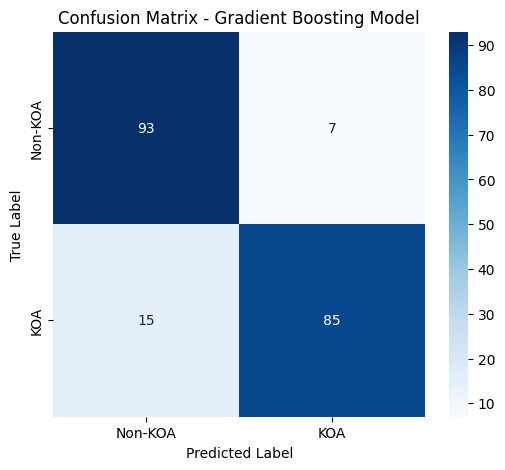

In [36]:
y_test_pred = best_gb.predict(X_test)

import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Non-KOA", "KOA"],
            yticklabels=["Non-KOA", "KOA"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Gradient Boosting Model")

plt.show()

In [37]:
import pandas as pd
import numpy as np

new_patient = pd.DataFrame([{
    "age": 41,
    "gender": "Female",
    "height": 161,
    "weight": 65,
    "occupation": "yes",
    "physical_activity_level": "low",
    "living_environment": "rural",
    "knee_pain": "no",
    "knee_pain_in_past_week": 4,
    "stifness_after_resting": "always",
    "knee_injuries": "yes",
    "swelling": "yes",
    "difficulty_in_performing": "walking long distances",
    "family_history": "yes",
    "obesity": "no",
    "diabetes": "no",
    "hypertension": "no",
    "vitaminD_deficiency": "no",
    "rheumatoid_arthritis": "no",
    "fbs": 102.27,
    "wbc": 5519.96,
    "platelets": 153755.64,
    "cs": 0.89,
    "cholesterol": 191.17,
    "crp": 0.69,
    "esr": 10.65,
    "rf": 7.73,
    "fbc": 5.2
}])

# BMI
new_patient["BMI"] = new_patient["weight"] / ((new_patient["height"] / 100) ** 2)

# one-hot encoding same as training
new_patient = pd.get_dummies(new_patient)

# align with training columns
new_patient = new_patient.reindex(columns=X_train.columns, fill_value=0)

# scale numeric columns
new_patient[numeric_cols] = scaler.transform(new_patient[numeric_cols])

# predict using best_xgb
prediction = best_gb.predict(new_patient)
probability = best_gb.predict_proba(new_patient)

print("Prediction:", prediction[0])
print("Probability:", probability[0])

if prediction[0] == 1:
    print("KOA Detected")
else:
    print("No KOA")

Prediction: 0
Probability: [0.79036434 0.20963566]
No KOA


In [38]:
import pandas as pd
import numpy as np

new_patient = pd.DataFrame([{
    "age": 69,
    "gender": "Female",
    "height": 151,
    "weight": 80,
    "occupation": "yes",
    "physical_activity_level": "low",
    "living_environment": "urban",
    "knee_pain": "yes",
    "knee_pain_in_past_week": 2,
    "stifness_after_resting": "never",
    "knee_injuries": "yes",
    "swelling": "no",
    "difficulty_in_performing": "sqatting",
    "family_history": "no",
    "obesity": "no",
    "diabetes": "no",
    "hypertension": "no",
    "vitaminD_deficiency": "yes",
    "rheumatoid_arthritis": "yes",
    "fbs": 122.79,
    "wbc": 8475.75,
    "platelets": 151766.58,
    "cs": 0.71,
    "cholesterol": 221.98,
    "crp": 6,
    "esr": 16.17,
    "rf": 19.61,
    "fbc": 4.47
}])

# BMI
new_patient["BMI"] = new_patient["weight"] / ((new_patient["height"] / 100) ** 2)

# one-hot encoding same as training
new_patient = pd.get_dummies(new_patient)

# align with training columns
new_patient = new_patient.reindex(columns=X_train.columns, fill_value=0)

# scale numeric columns
new_patient[numeric_cols] = scaler.transform(new_patient[numeric_cols])

# predict using best_xgb
prediction = best_gb.predict(new_patient)
probability = best_gb.predict_proba(new_patient)

print("Prediction:", prediction[0])
print("Probability:", probability[0])

if prediction[0] == 1:
    print("KOA Detected")
else:
    print("No KOA")

Prediction: 1
Probability: [0.11651944 0.88348056]
KOA Detected


In [39]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import joblib

pipeline = Pipeline([
    ("scaler", scaler),
    ("model", best_model)
])

joblib.dump(pipeline, "koa_best_model.pkl")

['koa_best_model.pkl']

In [40]:
import pandas as pd
import numpy as np

gb_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_gb.feature_importances_
}).sort_values("importance", ascending=False)

print("Top 15 GB feature_importances_:")
print(gb_importance.head(15))


Top 15 GB feature_importances_:
                   feature  importance
23                     crp    0.336993
24                     esr    0.326460
7   knee_pain_in_past_week    0.075210
6                knee_pain    0.068101
8   stifness_after_resting    0.051629
0                      age    0.045692
18                     fbs    0.039754
22             cholesterol    0.033897
29                     BMI    0.007155
26                     fbc    0.006046
25                      rf    0.003424
10                swelling    0.003358
21                      cs    0.001263
14                diabetes    0.000666
20               platelets    0.000178


In [41]:
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score

# Use your best model (XGB)
model = best_gb

# Permutation importance on TEST set
perm = permutation_importance(
    model, X_test, y_test,
    n_repeats=30,
    random_state=42,
    scoring="accuracy",
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

print("Test Accuracy:", accuracy_score(y_test, model.predict(X_test)))
print("\nTop 15 important features (Permutation Importance):")
print(importance_df.head())


Test Accuracy: 0.89

Top 15 important features (Permutation Importance):
                   feature  importance_mean  importance_std
24                     esr         0.129167        0.022989
23                     crp         0.089000        0.017243
7   knee_pain_in_past_week         0.014333        0.008439
0                      age         0.010167        0.005984
8   stifness_after_resting         0.009833        0.008009


Top 15 features by SHAP:
                   feature  mean_abs_shap
24                     esr       0.617646
23                     crp       0.583109
7   knee_pain_in_past_week       0.235847
6                knee_pain       0.223726
8   stifness_after_resting       0.221745
0                      age       0.208199
22             cholesterol       0.144176
18                     fbs       0.139419
29                     BMI       0.033900
26                     fbc       0.031068
10                swelling       0.024142
25                      rf       0.015045
14                diabetes       0.005164
21                      cs       0.005139
3                   weight       0.000767


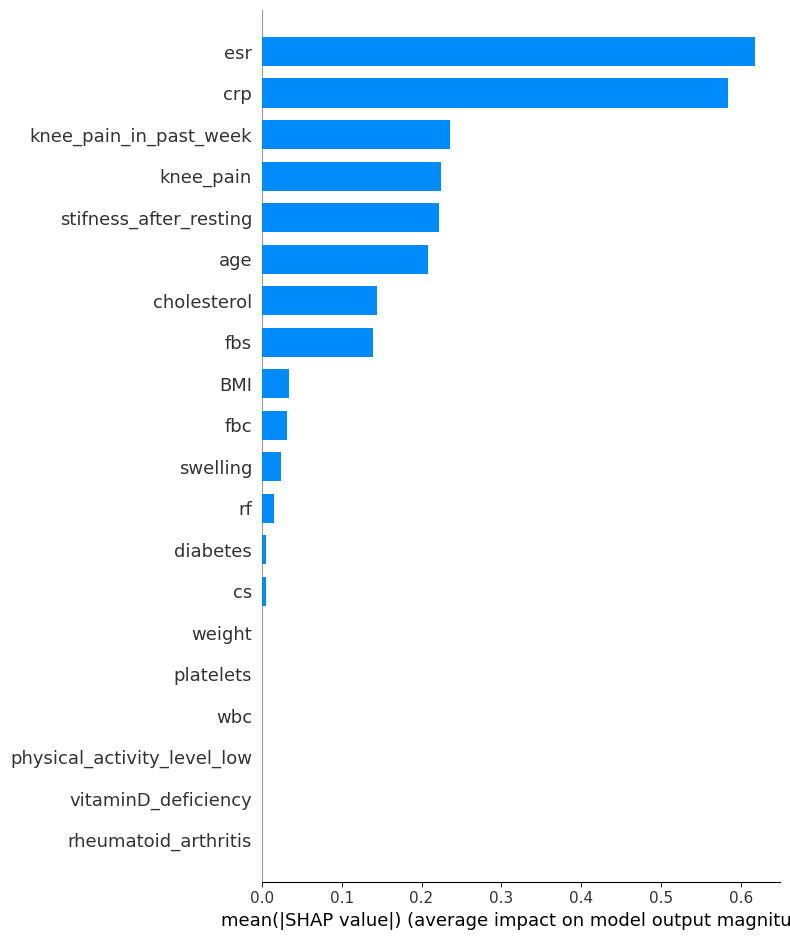

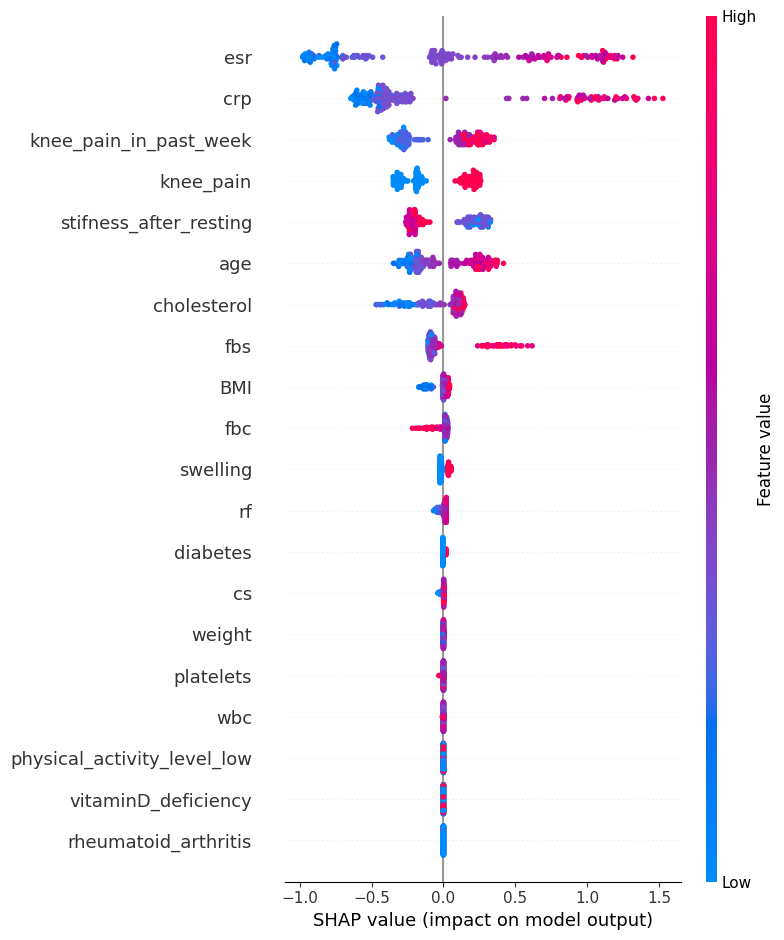

In [42]:
# pip install shap
import shap
import numpy as np
import pandas as pd

# use GB model for SHAP
model = best_gb

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Global importance (mean absolute SHAP value)
global_importance = pd.DataFrame({
    "feature": X_test.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

print("Top 15 features by SHAP:")
print(global_importance.head(15))

# Plot (optional)
shap.summary_plot(shap_values, X_test, plot_type="bar")
shap.summary_plot(shap_values, X_test)  # detailed

Predicted class: KOA
Prediction probabilities [Non-KOA, KOA]: [0.07726852 0.92273148]


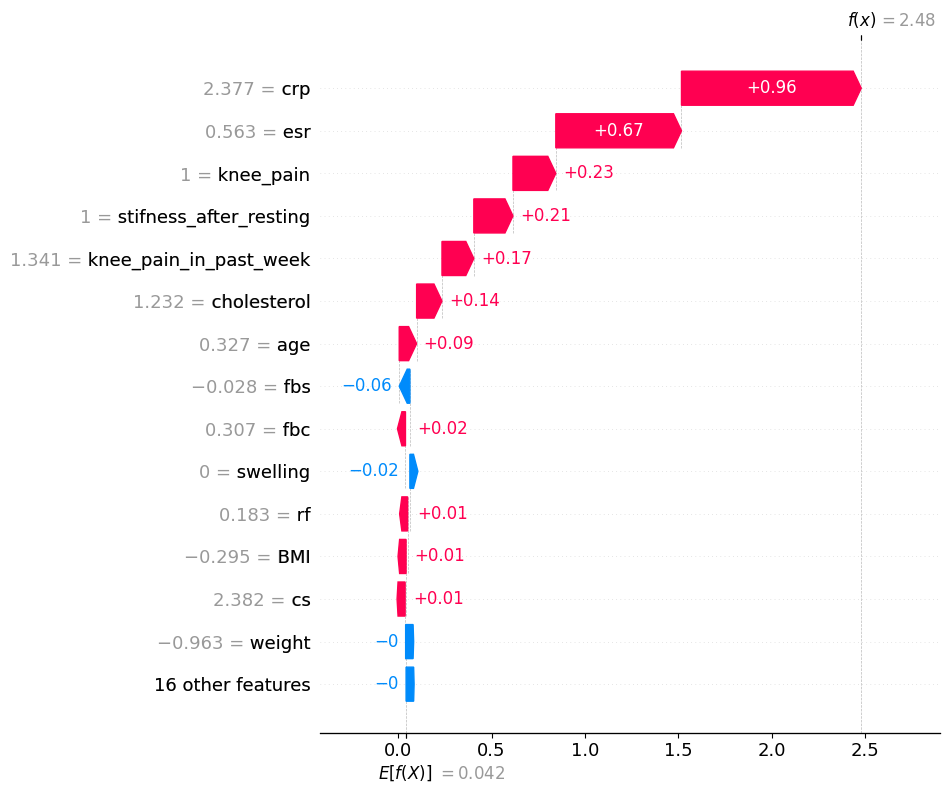

In [43]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Use final trained model
explainer = shap.TreeExplainer(best_gb)

# Pick one patient from test set
patient_index = 0
patient = X_test.iloc[[patient_index]]

# Prediction
pred_class = best_gb.predict(patient)[0]
pred_prob = best_gb.predict_proba(patient)[0]

print("Predicted class:", "KOA" if pred_class == 1 else "Non-KOA")
print("Prediction probabilities [Non-KOA, KOA]:", pred_prob)

# SHAP values for this patient
shap_values = explainer.shap_values(patient)

# For binary XGBoost, shap_values is usually (1, n_features)
patient_shap = shap_values[0]

# Base value
base_value = explainer.expected_value
if isinstance(base_value, list) or isinstance(base_value, np.ndarray):
    base_value = base_value[0]

# Create SHAP explanation object
explanation = shap.Explanation(
    values=patient_shap,
    base_values=base_value,
    data=patient.iloc[0],
    feature_names=patient.columns.tolist()
)

# Waterfall plot
shap.plots.waterfall(explanation, max_display=15)
plt.show()

In [44]:
# Create contribution table for the same patient
patient_contrib = pd.DataFrame({
    "feature": patient.columns,
    "feature_value": patient.iloc[0].values,
    "shap_value": patient_shap
})

patient_contrib["abs_shap"] = patient_contrib["shap_value"].abs()
patient_contrib = patient_contrib.sort_values("abs_shap", ascending=False)

print("Top patient-wise contributing features:")
print(patient_contrib.head(10)[["feature", "feature_value", "shap_value"]])

Top patient-wise contributing features:
                   feature feature_value  shap_value
23                     crp      2.377112    0.962741
24                     esr      0.562707    0.673117
6                knee_pain             1    0.229499
8   stifness_after_resting             1    0.209666
7   knee_pain_in_past_week      1.341439    0.170604
22             cholesterol      1.232255    0.135794
0                      age      0.327213    0.093218
18                     fbs     -0.027997   -0.057287
26                     fbc      0.306678    0.023850
10                swelling             0   -0.023637


Predicted class: KOA
Prediction probabilities [Non-KOA, KOA]: [0.11651944 0.88348056]


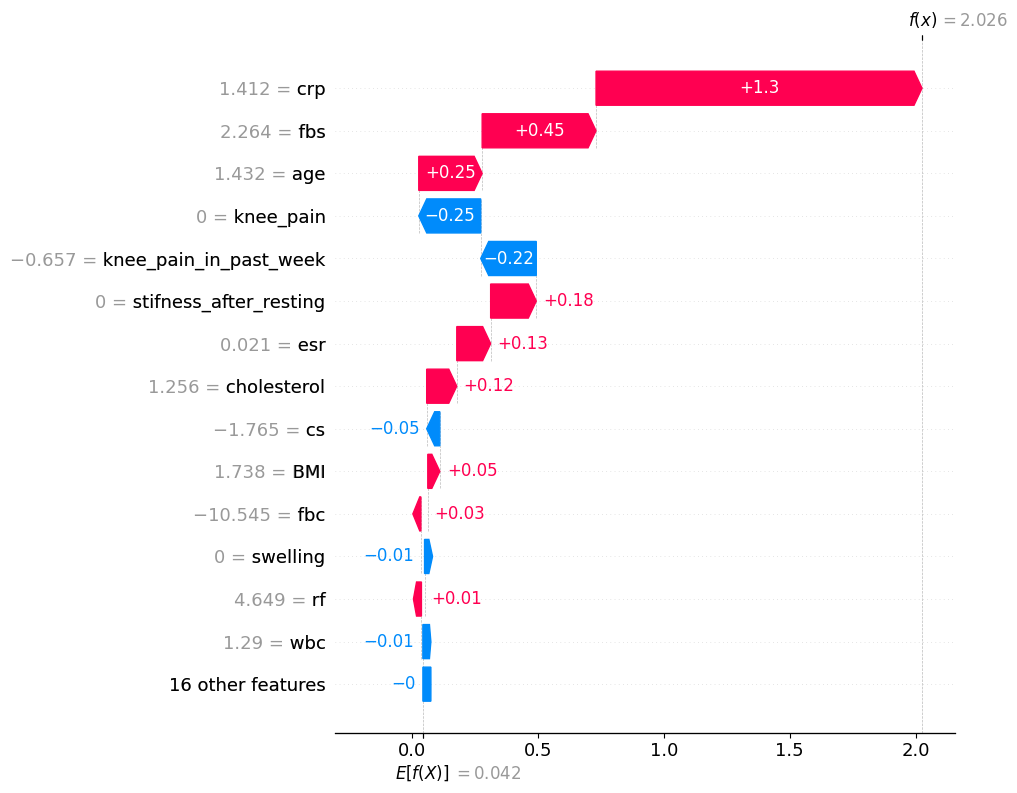

In [45]:
# Make sure new_patient has same columns in same order as X_train
new_patient = new_patient[X_train.columns]

pred_class = best_gb.predict(new_patient)[0]
pred_prob = best_gb.predict_proba(new_patient)[0]

print("Predicted class:", "KOA" if pred_class == 1 else "Non-KOA")
print("Prediction probabilities [Non-KOA, KOA]:", pred_prob)

shap_values_new = explainer.shap_values(new_patient)
new_patient_shap = shap_values_new[0]

explanation_new = shap.Explanation(
    values=new_patient_shap,
    base_values=base_value,
    data=new_patient.iloc[0],
    feature_names=new_patient.columns.tolist()
)

shap.plots.waterfall(explanation_new, max_display=15)
plt.show()

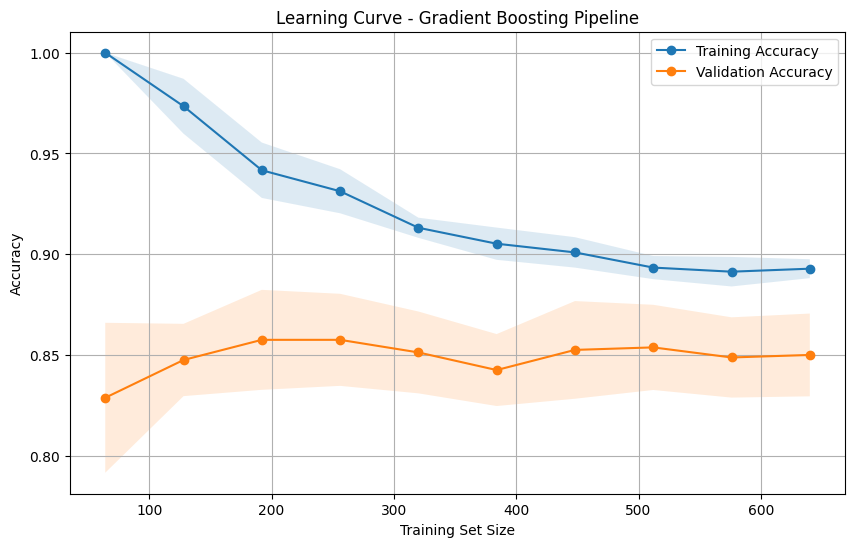

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

# best_rf, X_train, y_train are already available in your fixed notebook

train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_gb,
    X=X_train,
    y=y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

# Mean and std
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)

val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, marker='o', label='Training Accuracy')
plt.plot(train_sizes, val_mean, marker='o', label='Validation Accuracy')

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15)

plt.title("Learning Curve - Gradient Boosting Pipeline")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.grid(True)
plt.show()